<a href="https://colab.research.google.com/github/Vedant28082005/CV-2026-H10/blob/main/LAB4/CV_LAB_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

In [ ]:
img = cv2.imread("/content/sample.png" , cv2.IMREAD_GRAYSCALE)

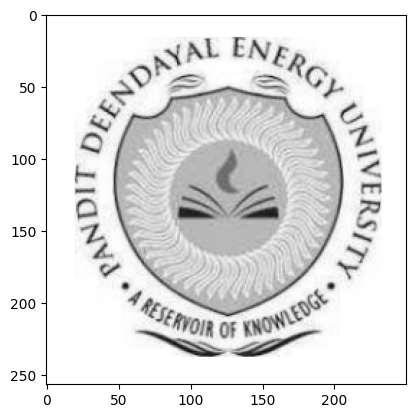

In [ ]:
plt.imshow(img , cmap='gray')

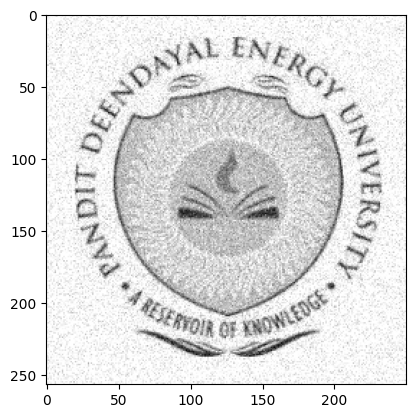

In [ ]:
noisy_image = img + np.random.normal(0, 20, img.shape)
noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
plt.imshow(noisy_image, cmap='gray')

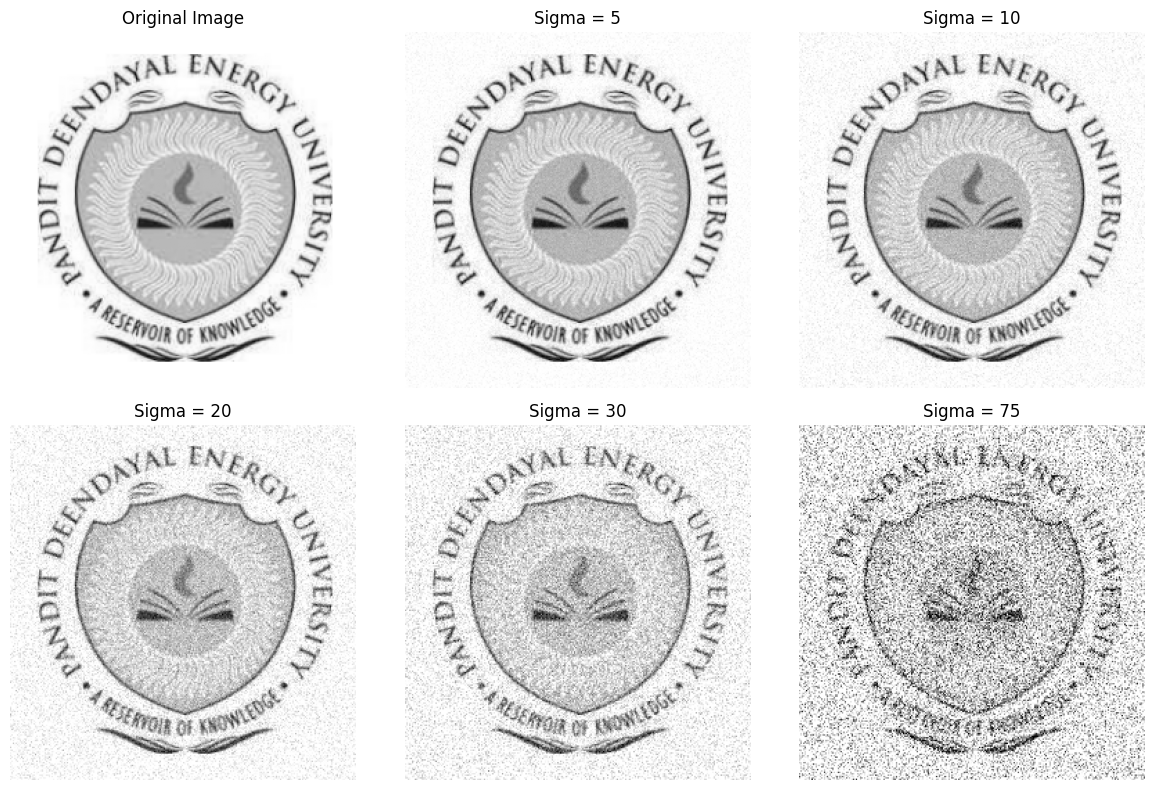

In [ ]:
sigma_values = [5, 10, 20, 30, 75]

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plot_no = 2

for sigma in sigma_values:

    noise = np.random.normal(0, sigma, img.shape)

    noisy_image = img.astype(np.float32) + noise

    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)

    plt.subplot(2, 3, plot_no)
    plt.imshow(noisy_image, cmap='gray')
    plt.title(f"Sigma = {sigma}")
    plt.axis('off')

    plot_no += 1

plt.tight_layout()
plt.show()

In [ ]:
def gaussian_filter(img, kernel_size=7, sigma=20):
    k = kernel_size // 2

    # Create Gaussian kernel
    x, y = np.mgrid[-k:k+1, -k:k+1]
    kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel /= np.sum(kernel)

    # Padding
    padded = np.pad( img, ((k, k), (k, k)), mode='edge')

    out_h, out_w = img.shape
    filtered = np.zeros((out_h, out_w), dtype=np.float32)

    # Convolution
    for i in range(out_h):
        for j in range(out_w):
            region = padded[i:i + kernel_size, j:j + kernel_size]
            filtered[i, j] = np.sum(region * kernel)

    return np.clip(filtered, 0, 255).astype(np.uint8)

(np.float64(-0.5), np.float64(249.5), np.float64(256.5), np.float64(-0.5))

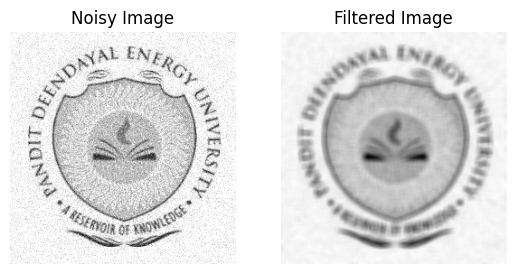

In [ ]:
filtered_image = gaussian_filter(noisy_image)

plt.subplot(1, 2, 1)
plt.title("Noisy Image")
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered_image, cmap='gray')
plt.title("Filtered Image")
plt.axis('off')